# Moliterate Filters
This tutorial shows how to make use of filters.

In [1]:
from pathlib import Path

import scm.moliterate as moliterate
from scm.moliterate import load_dataset

moliterate_path = Path(moliterate.__path__[0])
TUTORIAL_FOLDER = moliterate_path.parent.parent.parent / "tutorials"

<div class="alert alert-block alert-warning">
<b>Pre-requisites:</b> 
Before starting this tutorial be sure to know the basics explained in:

- __[quick-overview.ipynb](quick-overview.ipynb)__

- __[core-moliterate-concepts.ipynb](core-moliterate-concepts.ipynb)__
</div>

In [2]:
# Plotting tools
from typing import Optional

import matplotlib.pyplot as plt
import numpy as np

from scm.moliterate.core import BaseChemDataSet, BaseFilter, BasePartitionCriteria


def hist_partition_criterion(
        ds:BaseChemDataSet, 
        partition:BasePartitionCriteria, 
        alpha=0.6, 
        label='Initial dataset', 
        bins=None,
    ):
    data = partition(ds).ravel()
    
    _, bins, _ = plt.hist(data, alpha=alpha, label=label, bins=bins)
    plt.xlabel(f"{partition.name}")
    plt.legend()
    return bins

def compare_distribution(ds_filter:BaseFilter, ds:BaseChemDataSet, partition:BasePartitionCriteria):   
    bins = hist_partition_criterion(ds, partition, label='Initial dataset')
    _ = hist_partition_criterion(ds_filter(ds), partition, bins=bins, label=f'Selected Data')

def compare_scatter(ds_filter:BaseFilter, ds:BaseChemDataSet, 
                    partition:BasePartitionCriteria, 
                    partitionY:Optional[BasePartitionCriteria]=None, 
                    alpha=0.6):
    assert partitionY is not None
    xname, yname = partition.name, partitionY.name
    xdata = partition(ds).ravel()
    ydata = partitionY(ds).ravel()
    
    plt.plot(xdata, ydata, "o", alpha=alpha, label='Initial dataset')
    plt.plot(
        partition(ds_filter(ds)).ravel(), partitionY(ds_filter(ds)).ravel(), 
        "o",
        alpha=alpha, 
        label=f'Selected Data')
    plt.xlabel(f"{xname}")
    plt.ylabel(f"{yname}")
    plt.legend()

## What a filter is in moliterate

Filters are callables that given a `BaseChemDataSet` return a `BaseChemDataSet` with usually length less or equal the input one.

The simplest filter is the `slice`: let's collect entries from the 10th and the 20th skipping the odd ones.

In [3]:
from scm.moliterate.core.base_chem_dataset import BaseChemDataSet

ds:BaseChemDataSet = load_dataset(TUTORIAL_FOLDER/"data/params")
ds

ParAMSData(len=34, properties=['energy', 'forces'], transforms=[] at 0x7dbf1ba606d0)

In [4]:
ds_even_slice:BaseChemDataSet = ds[10:20:2]
ds_even_slice

ParAMSData(len=5, properties=['energy', 'forces'], transforms=[] at 0x7dbf1c6dd0e0)

In [5]:
[x.idx_absolute for x in ds_even_slice]

[10, 12, 14, 16, 18]

We now introduce the `filters` module, where we collect filters classes. Among these the simplest is the `RandomFilter`:

In [6]:
from scm.moliterate.filters import RandomFilter

take_3_random = RandomFilter(num_samples=3, seed=20)

ds_3_random = take_3_random(ds)
ds_3_random

ParAMSData(len=3, properties=['energy', 'forces'], transforms=[] at 0x7dbebec6f720)

## PartitionCriterion

When we need to filter a dataset we always need to choose a representation of the dataset for guiding a decision making. In moliterate partition criteria are used to build this representation.

A `PartitionCriterion` in moliterate is essentially a callable object that takes a BaseChemDataSet and returns a NumPy array of labels or numeric descriptors that drive grouping, splitting, or clustering. 

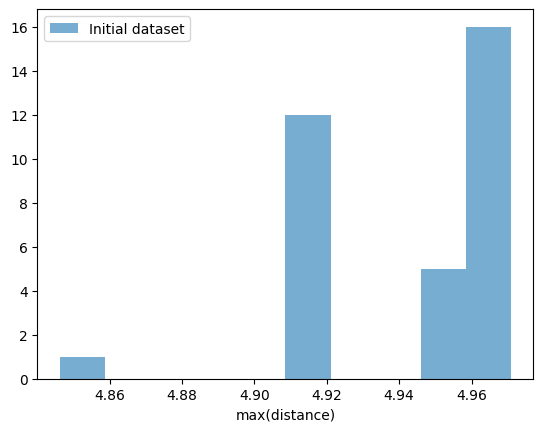

In [7]:
from scm.moliterate.partition_criteria import MaxDistanceCriterion

max_distance = MaxDistanceCriterion(min_image_convention=True)

_ = hist_partition_criterion(ds, max_distance)

Partition criteria can also calculate atomistic features vectors. For example let's use the interface of Many-body Tensor Representation (MBTR) descriptor of the [dscribe library](https://singroup.github.io/dscribe/latest/#). When using this package please use the >= 2.0.0 citation found [here](https://singroup.github.io/dscribe/latest/citing.html).

In [8]:
!pip install 'dscribe==2.1.1'
!pip install 'scikit-learn>=1.3.2'

In [12]:
from scm.moliterate.partition_criteria import MBTRCriterion

mbtr_descriptor = MBTRCriterion.auto_determine_mbtr_grid(
    ds, geometry_function="distance",
)

In [13]:
features_mbtr = mbtr_descriptor(ds)

Text(0.5, 1.0, 'Many-body Tensor Representation')

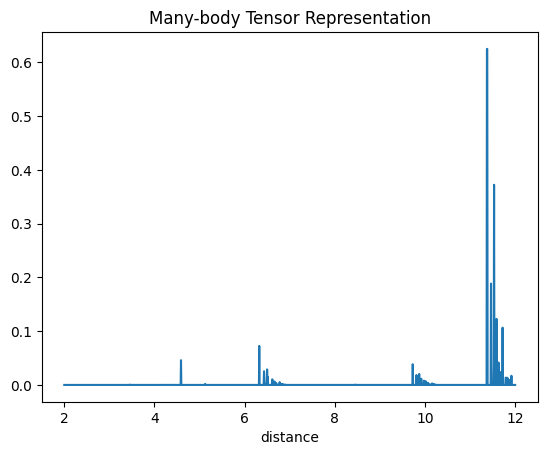

In [16]:
x = np.linspace(2, 12, features_mbtr.shape[-1])
plt.plot(x, features_mbtr[0,:])
plt.xlabel(f"{mbtr_descriptor.geometry_function}")
plt.title("Many-body Tensor Representation")

## Tour of built-in filters

We now go one by one all the available filters.

### ConditionsFilter
The conditions filters, allows to easy conditions checks.

In [ ]:
from scm.moliterate.filters import ConditionsFilter

training_set_filter = ConditionsFilter(
    conditions="energy>-823.13", 
)
training_set_filter(ds)

ParAMSData(len=9, properties=['energy', 'forces'], transforms=[] at 0x79787d0a9130)

You can change the `collect_from` to decide whether the value is collected from metadata, properties or properties_first:

In [ ]:
training_set_filter = ConditionsFilter(
    conditions="dataset=training_set", 
    collect_from="metadata",
)
training_set_filter(ds)

ParAMSData(len=27, properties=['energy', 'forces'], transforms=[] at 0x79787d0e22c0)

You can chain conditions using a string with comma separated conditions:

In [ ]:
training_set_filter = ConditionsFilter(
    conditions="dataset=training_set, Frame=3", 
    collect_from="metadata",
    combine_conditions_fun="all", # default value
)
training_set_filter(ds)

ParAMSData(len=1, properties=['energy', 'forces'], transforms=[] at 0x79787d0a5d10)

By default the collected value is `None` therefore you can end up with zero data:

In [ ]:
training_set_filter = ConditionsFilter(
    conditions="NotExists=1", 
    collect_from="metadata",
    default=False,
)
training_set_filter(ds)

ParAMSData(len=0, properties=['energy', 'forces'], transforms=[] at 0x79787d0cf360)

### TopNFilter

In [ ]:
from scm.moliterate.core.filters import BaseFilterError
from scm.moliterate.filters import TopNFilter
from scm.moliterate.partition_criteria import PropertyCriterion

top_n_energy = TopNFilter(
    partition_criterion=PropertyCriterion(property_key="energy"),
    num_samples=0.5,
)
top_n_energy(ds)

ParAMSData(len=17, properties=['energy', 'forces'], transforms=[] at 0x79787d09da90)

In [ ]:
top_n_fmax = TopNFilter(
    partition_criterion=PropertyCriterion(property_key="forces", post_process="l2_max"),
    num_samples=6,
)
top_n_fmax(ds)

ParAMSData(len=6, properties=['energy', 'forces'], transforms=[] at 0x79787d0e10e0)

Text(0.5, 1.0, 'TopNFilter @ max(||forces||)')

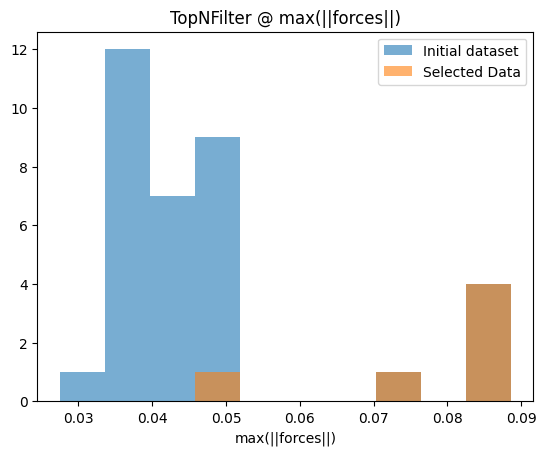

In [ ]:
compare_distribution(top_n_fmax, ds, partition=top_n_fmax.partition_criterion)
plt.title(f"{top_n_fmax.__class__.__name__} @ {top_n_fmax.partition_criterion.name}")

In [ ]:
top_n_failure = TopNFilter(
    partition_criterion=PropertyCriterion(property_key="forces"),
    num_samples=0.1,
)
try:
    top_n_failure(ds)
except BaseFilterError as e:
    print(f"{e}")

Something is wrong here: feature_values.shape=(34, 20, 3) with len(db)=34 and self.partition_criterion=PropertyCriterion(type='PropertyCriterion', property_key='forces', post_process=None, unit_transform=None)


### FarthestPointFilter

In [ ]:
from scm.moliterate.filters import FarthestPointFilter
from scm.moliterate.partition_criteria import GyrationRCriterion, PropertyCriterion

energy_criterion=PropertyCriterion(property_key="energy")

far_filter = FarthestPointFilter(
    partition_criterion=energy_criterion,
    num_samples=10,
    seed=10
)

Text(0.5, 1.0, 'FarthestPointFilter @ energy')

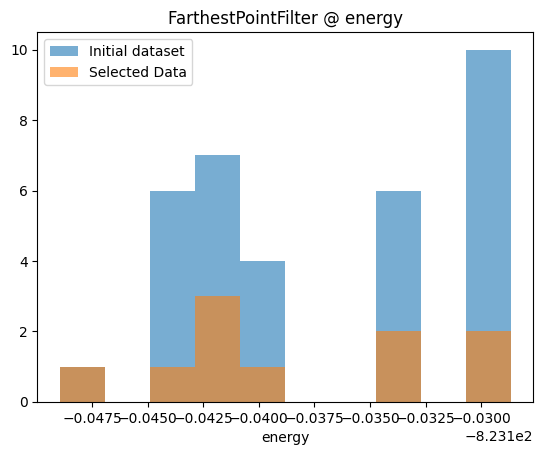

In [ ]:
compare_distribution(far_filter, ds, partition=far_filter.partition_criterion)
plt.title(f"{far_filter.__class__.__name__} @ {far_filter.partition_criterion.name}")

### Bitwise Filters: Pipe, And, Or, Not

There are 4 filters that allow you to combine other filters:

| Filter     | Operator | Description |
|------------|----------|-------------|
| PipeFilter | `>>`     | Pipes the output of one filter into the next, applying them sequentially. |
| AndFilter  | `&`      | Combines multiple filters and matches only when **all** conditions are satisfied. |
| OrFilter   | `\|`      | Combines multiple filters and matches when **at least one** condition is satisfied. |
| NotFilter  | `~`      | Negates a filter, matching when the condition is **not** satisfied. |


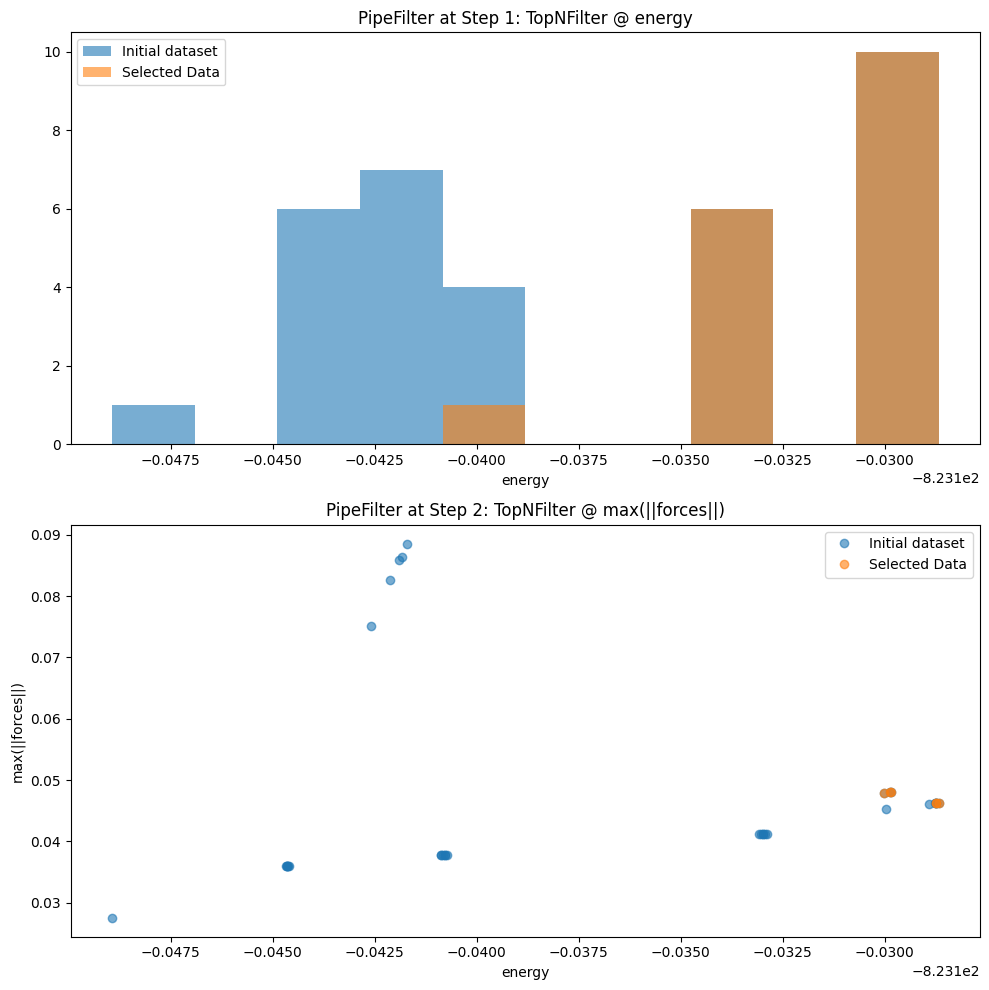

In [ ]:
from scm.moliterate.filters import PipeFilter

top_energy_and_fmax = PipeFilter(filters=[top_n_energy, top_n_fmax])


plt.figure(figsize=(10,10))
plt.subplot(2,1,1)
compare_distribution(
    top_n_energy, 
    ds, 
    partition=top_n_energy.partition_criterion,
)
plt.title(f"PipeFilter at Step 1: {top_n_energy.__class__.__name__} @ {top_n_energy.partition_criterion.name}")

plt.subplot(2,1,2)
compare_scatter(
    top_energy_and_fmax, 
    ds, 
    partition=top_n_energy.partition_criterion,
    partitionY=top_n_fmax.partition_criterion,
)
plt.title(f"PipeFilter at Step 2: {top_n_fmax.__class__.__name__} @ {top_n_fmax.partition_criterion.name}")
plt.tight_layout()

For the `PipeFilter` the corresponding operator is: `>>`

In [ ]:
pipe_filter_shortcut = top_n_energy >> top_n_fmax
pipe_filter_shortcut == top_energy_and_fmax

True

Text(0.5, 1.0, 'AndFilter: TopNFilter@energy AND TopNFilter@max(||forces||)')

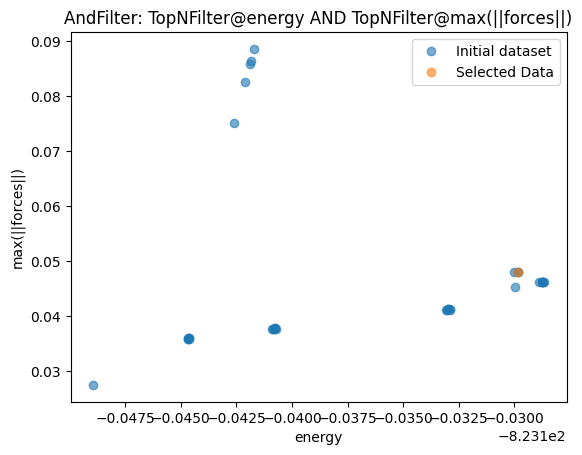

In [ ]:
and_filter = top_n_energy & top_n_fmax
compare_scatter(
    and_filter,
    ds, 
    partition=top_n_energy.partition_criterion,
    partitionY=top_n_fmax.partition_criterion,
)
plt.title((f"AndFilter: "
           f"{top_n_energy.__class__.__name__}@{top_n_energy.partition_criterion.name} "
           f"AND {top_n_fmax.__class__.__name__}@{top_n_fmax.partition_criterion.name}"))

Text(0.5, 1.0, 'AndFilter: TopNFilter OR TopNFilter')

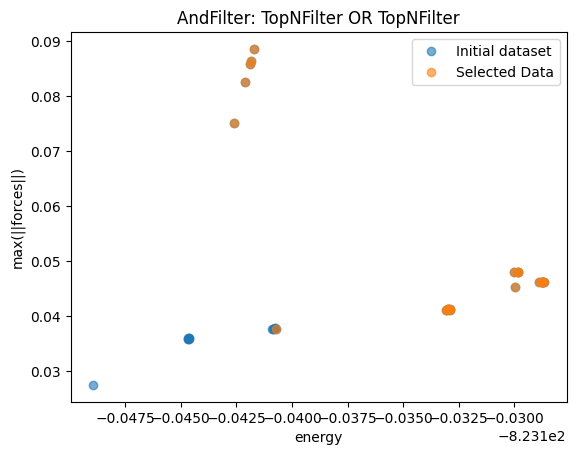

In [ ]:
or_filter = top_n_energy | top_n_fmax
compare_scatter(
    or_filter, 
    ds, 
    partition=top_n_energy.partition_criterion,
    partitionY=top_n_fmax.partition_criterion,
)
plt.title(f"AndFilter: {top_n_energy.__class__.__name__} OR {top_n_fmax.__class__.__name__}")

Text(0.5, 1.0, '~ top_n_energy >> top_n_fmax')

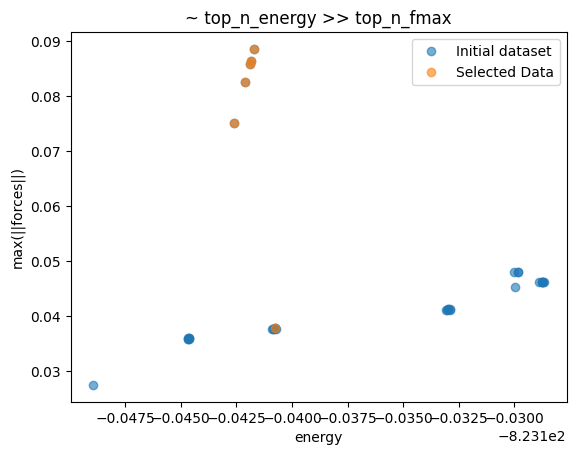

In [ ]:
combined_filter = ~ top_n_energy >> top_n_fmax
compare_scatter(
    combined_filter, 
    ds, 
    partition=top_n_energy.partition_criterion,
    partitionY=top_n_fmax.partition_criterion,
)
plt.title(f"~ top_n_energy >> top_n_fmax")

### RemoveDuplicates

In [ ]:
from scm.moliterate.filters import RemoveDuplicates
from scm.moliterate.partition_criteria import (
    AgglomerativeHierarchicalClustering,
    GyrationRFmaxCriterion,
)

agglomerate_criterion = AgglomerativeHierarchicalClustering(
        partition_criterion=GyrationRFmaxCriterion(),
        fcluster_threshold=0.01,
)
duplicate_remover = RemoveDuplicates(
    clustering_algorithm=agglomerate_criterion,
    selection_strategy=RandomFilter(num_samples=2),
)

In [ ]:
dendogram = agglomerate_criterion.run(ds)

<Axes: title={'center': 'Dendrogram C:distance, t=0.01'}, xlabel='Sample Index', ylabel='Distance'>

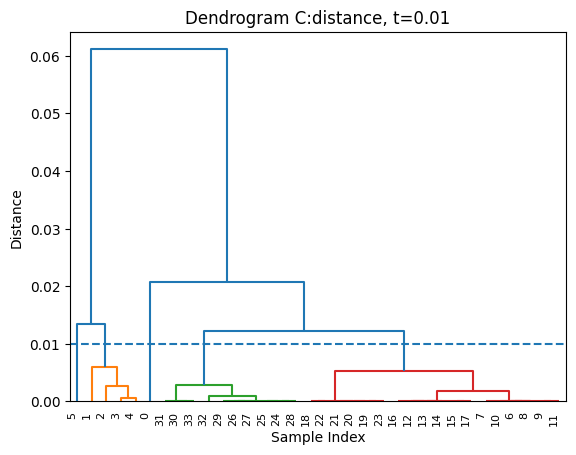

In [ ]:
dendogram.plot()

In [ ]:
duplicate_remover(ds)

/home/benedini/AL_refactoring_project/active_learning_workspace/moliterate/src/scm/moliterate/filters/scalar_filters.py:110: BaseFilterWarning: No Filter will occur: n_data=2 > n_entries=1
  warnings.warn(f"No Filter will occur: {n_data=} > {n_entries=}", BaseFilterWarning)


ParAMSData(len=8, properties=['energy', 'forces'], transforms=[] at 0x79787c9b8180)

Text(0.5, 1.0, 'duplicate_remover: AgglomerativeHierarchicalClustering to RandomFilter')

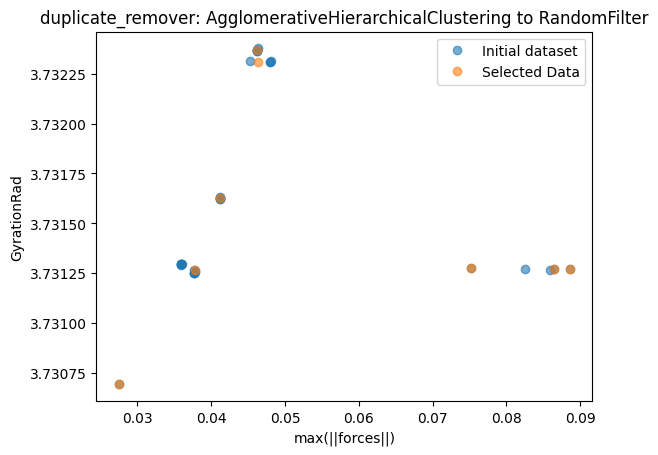

In [ ]:
from scm.moliterate.partition_criteria import (
    GyrationRCriterion,
)

compare_scatter(
    duplicate_remover, 
    ds,
    partition=PropertyCriterion(property_key="forces", post_process="l2_max"),
    partitionY=GyrationRCriterion(),
)
plt.title(f"duplicate_remover: AgglomerativeHierarchicalClustering to RandomFilter")

### ApricotFilter

This is an interface over the [apricot](https://apricot-select.readthedocs.io/en/latest/index.html) package. Please consider citing the [manuscript](https://www.jmlr.org/papers/v21/19-467.html) if you use apricot in your academic work. To install:

In [ ]:
!pip install 'apricot-select>=0.6.1'

In [ ]:
from scm.moliterate.filters import ApricotFilter
from scm.moliterate.partition_criteria import (
    GyrationRFmaxCriterion,
)

In [ ]:
partition_gyr_fmax=GyrationRFmaxCriterion()

max_cov_on_gyr_fmax = ApricotFilter(
    n_samples=5, 
    partition_criterion=partition_gyr_fmax, 
    selection_strategy="MaxCoverageSelection",
    random_state=10,
)

facility_on_gyr_fmax = ApricotFilter(
    n_samples=5, 
    partition_criterion=partition_gyr_fmax, 
    selection_strategy="FacilityLocationSelection",
    random_state=10,
)

far_on_gyr_fmax_filter = FarthestPointFilter(
    partition_criterion=partition_gyr_fmax,
    num_samples=5,
    seed=10
)

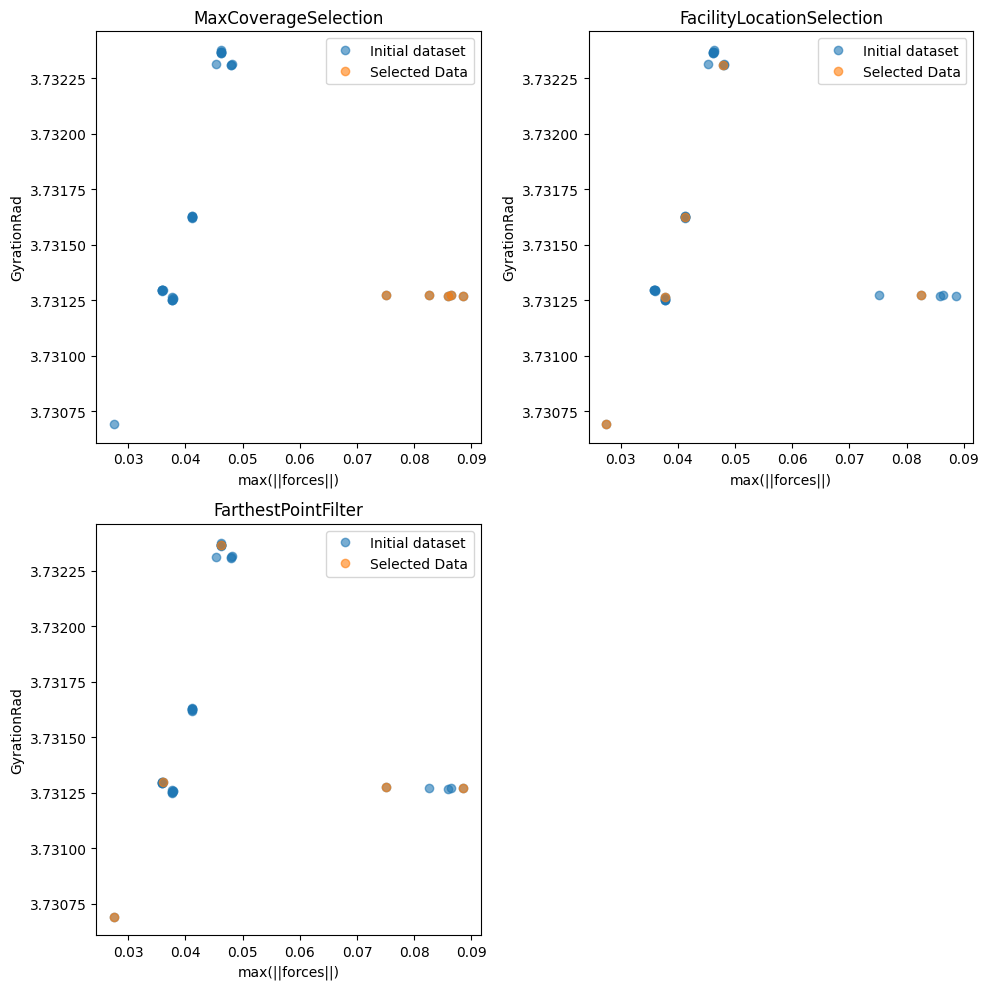

In [ ]:
plt.figure(figsize=(10,10))
plt.subplot(2,2,1)
compare_scatter(
    max_cov_on_gyr_fmax, 
    ds, 
    partition=PropertyCriterion(property_key="forces", post_process="l2_max"),
    partitionY=GyrationRCriterion(),
)
plt.title("MaxCoverageSelection")

plt.subplot(2,2,2)
compare_scatter(
    facility_on_gyr_fmax, 
    ds, 
    partition=PropertyCriterion(property_key="forces", post_process="l2_max"),
    partitionY=GyrationRCriterion(),
)
plt.title("FacilityLocationSelection")

plt.subplot(2,2,3)
compare_scatter(
    far_on_gyr_fmax_filter, 
    ds, 
    partition=PropertyCriterion(property_key="forces", post_process="l2_max"),
    partitionY=GyrationRCriterion(),
)
plt.title("FarthestPointFilter")
plt.tight_layout()

## Nest Septs

Other tutorials in increasing order of complexity:

- __[advanced-create-an-interface.ipynb](advanced-create-an-interface.ipynb)__